In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import plotly.express as px

from scipy.stats import skew
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from astropy.timeseries import LombScargle
from scipy.interpolate import interp1d

In [50]:
data = []
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

def to_float(x):
    if x == "-":
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

with open("list.dat", "r") as f:
    for line in f:
        parts = line.split()
        # Ignorar líneas vacías
        if len(parts) < 5:
            continue
        obj_id = parts[0]
        ra = parts[1]
        dec = parts[2]
        # Buscar inicio de columnas numéricas
        first_num = None
        for i in range(3, len(parts)):
            if is_float(parts[i]) or parts[i] == "-":
                first_num = i
                break
        if first_num is None:
            continue
        # Clasificaciones
        class_parts = parts[3:first_num]
        tipo1 = class_parts[0] if len(class_parts) > 0 else None
        tipo2 = class_parts[1] if len(class_parts) > 1 else None
        # Extraer columnas de forma segura
        mag_I = to_float(parts[first_num]) if len(parts) > first_num else np.nan
        mag_V = to_float(parts[first_num + 1]) if len(parts) > first_num + 1 else np.nan
        periodo = to_float(parts[first_num + 2]) if len(parts) > first_num + 2 else np.nan
        amplitud = to_float(parts[first_num + 3]) if len(parts) > first_num + 3 else np.nan
        
        data.append([obj_id,ra,dec,tipo1,tipo2,mag_I,mag_V,periodo,amplitud])

df = pd.DataFrame(data, columns=["ID","RA","DEC","Tipo","Subtipo","I","V","Periodo","Amplitud"])

print(df.head())
print(df.shape)

               ID           RA          DEC   Tipo Subtipo       I       V  \
0   LMC563.16.842  05:46:55.53  -66:30:47.6  OTHER    None  18.925  18.981   
1  LMC563.16.1142  05:46:57.17  -66:24:53.9  RRLYR    RRab  19.091  19.745   
2     LMC563.16.8  05:46:57.78  -66:26:43.4    LPV   OSARG  14.662  16.383   
3  LMC563.16.9286  05:46:59.24  -66:18:01.0    ECL    None  18.690  18.808   
4  LMC563.16.2137  05:47:00.94  -66:25:36.0  OTHER    None  19.526  19.529   

      Periodo  Amplitud  
0    1.850940     0.069  
1    0.494447     0.839  
2  369.000000     0.045  
3    0.972667     0.264  
4    0.850470     0.142  
(6789, 9)


In [51]:
# 1. Agrupar por la clase principal ('Tipo') y contar
# 'value_counts' ya los ordena de mayor a menor por defecto
conteo_clases = df['Tipo'].value_counts()
print("\n" + "="*40)
print("RESUMEN DE ESTRELLAS POR CLASE PRINCIPAL")
print("="*40)
# 2. Imprimir los resultados con un formato claro
for clase, cantidad in conteo_clases.items():
    print(f"{clase:<15} : {cantidad:>8} objetos")
print("-" * 40)
print(f"{'TOTAL':<15} : {conteo_clases.sum():>8} objetos")
print("="*40)


RESUMEN DE ESTRELLAS POR CLASE PRINCIPAL
LPV             :     2799 objetos
OTHER           :     1473 objetos
ECL             :     1376 objetos
RRLYR           :      686 objetos
DSCT            :      159 objetos
ELL             :      156 objetos
DCEP            :      132 objetos
T2CEP           :        5 objetos
ACEP            :        3 objetos
----------------------------------------
TOTAL           :     6789 objetos


Pulsadores radiales(RRKYR, DSCUTI, DCEPHEID, T2CEPHEID, ANOMALOUSCEPHEID)

En su mayoría, pulsan con menos de 20 días de periodo, aunque algunas lo hacen por más, y las cefeidas clásicas se reportan a más de 100 días. 


Todas tienen varios modos de oscilación, 


Delta Scuti variables are fainter, have shorter pulsation periods, and smaller masses than classical Cepheids, but both groups obey the same period-luminosity relation and it is simply a matter of convention which period defines a boundary between them.


Además, todas son "toboganes" hacia la derecha

LPVARIABLES

OTHER

BINARYECLIPSANTES, ELLIPSOIDALES

Iguales, o similares, porque las binarias eclipsantes tienen un eclipse grande y otro más pequeño, y lo mismo pasa con las elipsoidales. Mientras que con las unas es por el brillo entre una y su compañera, para las elipsoidales es porque una de las dos estrellas hala a la otra y le da una forma de elipse: los polos son más brillantes que el ecuador, y se nota mucho del lado puntiagudo de la estrella.

In [52]:
#Este código es para separar las clases de las features. YUPIIII

¿Qué features poner?

TEnemos que conocer el periodo. Una vez conocido el periodo(lo da el documento, pero volverlo a buscar con Lomb Scargle?), cómo hacemos para saber que la distribución magnitud contra fase es sinusoidal, diente de sierra, etc? 


Tenemos los datos fotométricos, así que hacer LS no es imposible, y lo haríamos todo en I.


Ahora, para distinguir formas de funciones, podemos buscar distancia en fase entre mínimos y máximos, y máximos y mínimos. la primera es muy corta para dientes de sierra, y la segunda muy larga. Para las otras, es más estándar y su diferencia debería ser cercana a cero.


Además, comparar mínimos y máximos entre sí nos ayuda a las binarias, diría yo. Pero y la precesión de Herzprung no nos jodería ahí?


PERIODO, DELTA MIN-MAX, DELTA MAX-MIN, DELTA MIN-MIN

Va a tocar tener en consideración cómo hacemos para las binarias, porque lomb scargle a un orden no va a funcionar... serían 12, y no va a dar en esta vida. Pero la gran mayoría funciona! podemos encontrar otra manera que no sea MIN-MIN para claificarlas?

La Amplitud cómo nos ayuda?

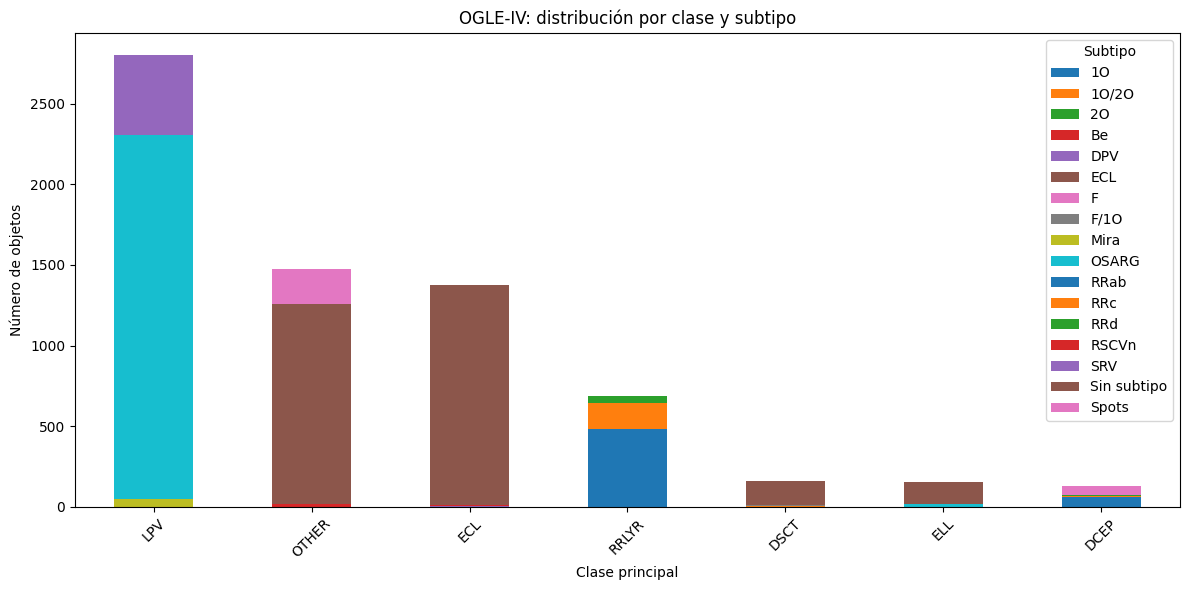

In [53]:
# Eliminar T2CEP y ACEP
df_filtered = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()
# Subtipos vacíos
df_filtered["Subtipo"] = df_filtered["Subtipo"].fillna("Sin subtipo")
# Conteos
counts = (df_filtered.groupby(["Tipo", "Subtipo"]).size().unstack(fill_value=0))
# Ordenar por abundancia
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
# Histograma apilado
ax = counts.plot(kind="bar",stacked=True,figsize=(12,6))

plt.xlabel("Clase principal")
plt.ylabel("Número de objetos")
plt.title("OGLE-IV: distribución por clase y subtipo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Eliminamos columnas innecesarias y nos preparamos para encontrar las features interesantes que mencionamos anteriormente:


Periodo


Deltas Min-Max, Max-Min, Min-Min

In [54]:
# Eliminar clases no deseadas
df = df[~df["Tipo"].isin(["T2CEP", "ACEP"])].copy()

# Eliminar filas sin período OGLE
df_sin_periodo = df[df["Periodo"].isna()].copy()
df = df[df["Periodo"].notna()].copy()

# Eliminar columnas innecesarias
df = df.drop(columns=["RA", "DEC", "V"])

# Reiniciar índices
df.reset_index(drop=True, inplace=True)

print(df.head())
print(df.shape)

               ID   Tipo Subtipo       I     Periodo  Amplitud
0   LMC563.16.842  OTHER    None  18.925    1.850940     0.069
1  LMC563.16.1142  RRLYR    RRab  19.091    0.494447     0.839
2     LMC563.16.8    LPV   OSARG  14.662  369.000000     0.045
3  LMC563.16.9286    ECL    None  18.690    0.972667     0.264
4  LMC563.16.2137  OTHER    None  19.526    0.850470     0.142
(6705, 6)


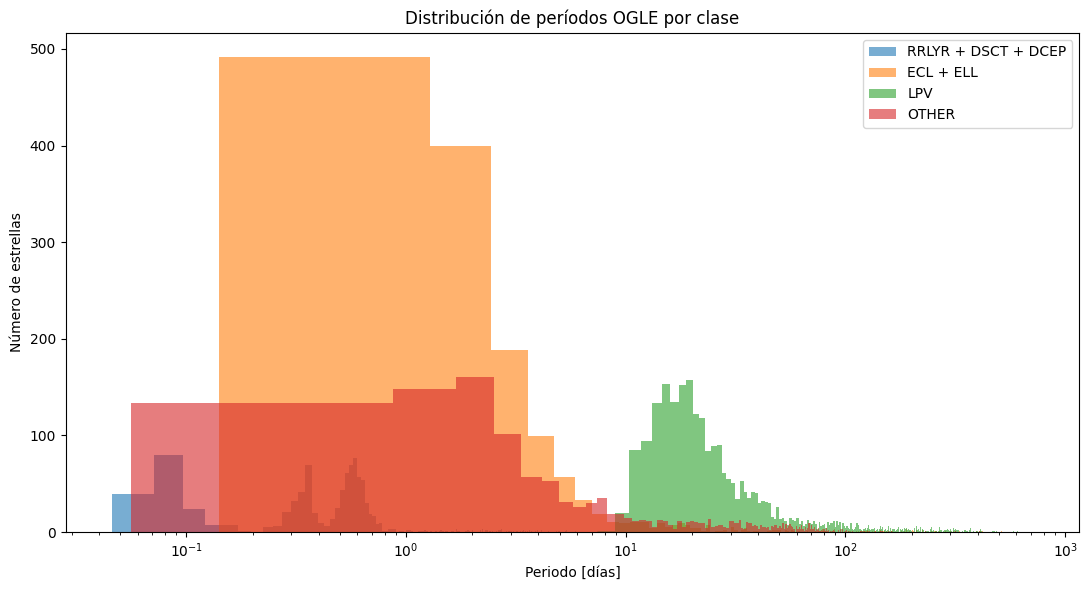

In [55]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

df_puls = df[df["Tipo"].isin(pulsantes)]
df_bin = df[df["Tipo"].isin(binarias)]
df_lpv = df[df["Tipo"].isin(lpv)]
df_other = df[df["Tipo"].isin(other)]

plt.figure(figsize=(11,6))
plt.hist(df_puls["Periodo"].dropna(),bins=500,alpha=0.6,label="RRLYR + DSCT + DCEP")
plt.hist(df_bin["Periodo"].dropna(),bins=500,alpha=0.6,label="ECL + ELL")
plt.hist(df_lpv["Periodo"].dropna(),bins=500,alpha=0.6,label="LPV")
plt.hist(df_other["Periodo"].dropna(),bins=500,alpha=0.6,label="OTHER")

plt.xscale("log")
plt.xlabel("Periodo [días]")
plt.ylabel("Número de estrellas")
plt.title("Distribución de períodos OGLE por clase")
plt.legend()
plt.tight_layout()
plt.show()

Empezar a correr desde acá cuando ya se ha hecho más de una vez, o correr desde el principio.

In [56]:
# Separación reproducible
df_train, df_classify = train_test_split(df,train_size=1000,random_state=42,shuffle=True)

# Reiniciar índices
df_train = df_train.reset_index(drop=True)
df_classify = df_classify.reset_index(drop=True)

print("Entrenamiento:", df_train.shape)
print("Clasificación:", df_classify.shape)

Entrenamiento: (1000, 6)
Clasificación: (5705, 6)


In [57]:
PHOT_PATH = "phot/I"

def load_lightcurve(star_id):
    filepath = os.path.join(PHOT_PATH, f"{star_id}.dat")
    if not os.path.exists(filepath):
        return None, None, None
    try:
        data = np.loadtxt(filepath)
        t = data[:,0]
        mag = data[:,1]
        err = data[:,2]
        return t, mag, err
    except:
        return None, None, None

In [58]:
def lomb_scargle_period(t,mag,star_type=None,subtype=None,samples_per_peak=10):
    # -----------------------------
    # Limpiar datos
    # -----------------------------
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]
    if len(t) < 30:
        return np.nan, None, None
    # -----------------------------
    # Centrar magnitudes
    # -----------------------------
    mag = mag - np.median(mag)
    # -----------------------------
    # Rangos físicos
    # -----------------------------
    min_period = 0.05
    max_period = 1000
    if star_type == "RRLYR":
        min_period = 0.15
        max_period = 1.2
    elif star_type == "LPV":
        # Subtipos LPV
        if subtype == "OSARG":
            min_period = 5
            max_period = 100
        elif subtype == "SRV":
            min_period = 10
            max_period = 300
        elif subtype == "Mira":
            min_period = 50
            max_period = 1500
        else:
            min_period = 5
            max_period = 500
    elif star_type == "ECL":
        min_period = 0.1
        max_period = 100
    elif star_type == "DCEP":
        min_period = 0.5
        max_period = 150
    # -----------------------------
    # Frecuencias
    # -----------------------------
    max_frequency = 1/min_period
    min_frequency = max(1/max_period,1/(t.max() - t.min()))
    # -----------------------------
    # Lomb Scargle
    # -----------------------------
    ls = LombScargle(t,mag,center_data=True)
    frequency, power = ls.autopower(minimum_frequency=min_frequency,maximum_frequency=max_frequency,samples_per_peak=samples_per_peak)
    # -----------------------------
    # Ordenar TODOS los picos
    # -----------------------------
    sorted_idx = np.argsort(power)[::-1]
    aliases = [1.0, 0.5, 2.0]
    best_period = None
    for idx in sorted_idx[:50]:
        period = 1 / frequency[idx]
        # -------------------------
        # Evitar aliases
        # -------------------------
        bad_alias = False
        for alias in aliases:
            if abs(period - alias) < 0.05:
                bad_alias = True
                break
        if bad_alias:
            continue
        # -------------------------
        # Restricciones LPV
        # -------------------------
        if star_type == "LPV":
            if period < 5:
                continue
        best_period = period
        break
    # -----------------------------
    # Fallback
    # -----------------------------
    if best_period is None:
        best_period = 1 / frequency[np.argmax(power)]
    # -----------------------------
    # Eclipsantes
    # -----------------------------
    if star_type == "ECL":
        best_period *= 2
    # Detectar soluciones pegadas al borde
    if best_period > 0.95 * max_period:
        best_period = np.nan
    return best_period, frequency, power

Pruebas sobre una estrella

In [59]:
sample_stars = df_train.sample(n=10,random_state=42).reset_index(drop=True)

print(sample_stars[["ID", "Tipo", "Subtipo"]])

                ID Tipo Subtipo
0   LMC570.25.3794  ECL    None
1   LMC563.08.6573  LPV     SRV
2   LMC563.32.5648  LPV   OSARG
3     LMC563.31.13  LPV     SRV
4   LMC571.26.3075  LPV   OSARG
5  LMC563.30.11681  ECL    None
6   LMC570.04.7043  LPV   OSARG
7   LMC563.25.7071  LPV   OSARG
8   LMC563.03.7842  LPV   OSARG
9     LMC571.32.17  LPV   OSARG


In [60]:
def phase_fold(t, period):
    phase = (t % period) / period
    return phase

In [61]:
"""for i, star in sample_stars.iterrows():

    print("="*60)
    print(f"Estrella {i+1}/10")
    print("ID:", star["ID"])
    print("Tipo:", star["Tipo"])
    print("Subtipo:", star["Subtipo"])

    # --------------------------------------------------------
    # Cargar curva
    # --------------------------------------------------------

    t, mag, err = load_lightcurve(star["ID"])

    if t is None:
        print("No se pudo cargar la curva.")
        continue

    print("N puntos:", len(t))

    # --------------------------------------------------------
    # Curva original
    # --------------------------------------------------------

    plt.figure(figsize=(10,4))

    plt.scatter(t, mag, s=3)

    plt.gca().invert_yaxis()

    plt.xlabel("JD")
    plt.ylabel("Magnitud I")

    plt.title(
        f"{star['ID']} | Curva de luz"
    )

    plt.show()

    # --------------------------------------------------------
    # Lomb Scargle
    # --------------------------------------------------------

    period_ls, freq, power = lomb_scargle_period(
        t,
        mag,
        star_type=star["Tipo"],
        subtype=star["Subtipo"]
    )

    print("Periodo OGLE:", star["Periodo"])
    print("Periodo LS:", period_ls)

    if np.isnan(period_ls):
        print("Periodo inválido.")
        continue

    # --------------------------------------------------------
    # Periodograma
    # --------------------------------------------------------

    plt.figure(figsize=(10,4))

    plt.plot(
        1/freq,
        power
    )

    plt.xscale("log")

    plt.xlabel("Periodo [días]")
    plt.ylabel("Potencia")

    plt.title(
        f"{star['ID']} | Lomb-Scargle"
    )

    plt.show()

    # --------------------------------------------------------
    # Curva plegada
    # --------------------------------------------------------

    phase = phase_fold(t, period_ls)

    plt.figure(figsize=(7,5))

    plt.scatter(
        phase,
        mag,
        s=3
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Fase")
    plt.ylabel("Magnitud")

    plt.title(
        f"{star['ID']} | Curva plegada | P={period_ls:.5f}"
    )

    plt.show()"""

'for i, star in sample_stars.iterrows():\n\n    print("="*60)\n    print(f"Estrella {i+1}/10")\n    print("ID:", star["ID"])\n    print("Tipo:", star["Tipo"])\n    print("Subtipo:", star["Subtipo"])\n\n    # --------------------------------------------------------\n    # Cargar curva\n    # --------------------------------------------------------\n\n    t, mag, err = load_lightcurve(star["ID"])\n\n    if t is None:\n        print("No se pudo cargar la curva.")\n        continue\n\n    print("N puntos:", len(t))\n\n    # --------------------------------------------------------\n    # Curva original\n    # --------------------------------------------------------\n\n    plt.figure(figsize=(10,4))\n\n    plt.scatter(t, mag, s=3)\n\n    plt.gca().invert_yaxis()\n\n    plt.xlabel("JD")\n    plt.ylabel("Magnitud I")\n\n    plt.title(\n        f"{star[\'ID\']} | Curva de luz"\n    )\n\n    plt.show()\n\n    # --------------------------------------------------------\n    # Lomb Scargle\n    # -

Aquí se acaban las puebas sobre la estrella

In [62]:
results = []

for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, period_grid, power = lomb_scargle_period(
            t,
            mag,
            star_type=star["Tipo"],
            subtype=star["Subtipo"])
        results.append({
            "ID": star["ID"],
            "Tipo": star["Tipo"],
            "Subtipo": star["Subtipo"],
            "Periodo_OGLE": star["Periodo"],
            "Periodo_LS": period_ls})
    except:
        continue

features_df = pd.DataFrame(results)
print(features_df)

                 ID   Tipo Subtipo  Periodo_OGLE  Periodo_LS
0    LMC563.08.8034    ECL    None      0.748787    0.748773
1    LMC571.01.4321    LPV   OSARG     21.841000   21.828878
2    LMC562.21.9858  OTHER    None      1.645070    1.644931
3    LMC563.21.3909    ECL    None      0.596507    0.596521
4    LMC562.19.8132    ECL    None      0.580783    0.580774
..              ...    ...     ...           ...         ...
995   LMC562.02.683    ECL    None      3.459870    3.460264
996  LMC570.22.5125    LPV   OSARG     49.890000   50.114744
997  LMC570.30.3312    ECL    None      0.959039    1.846945
998  LMC571.12.4453  RRLYR    RRab      0.632495    0.632444
999  LMC562.32.5326   DSCT    None      0.078112    0.078112

[1000 rows x 5 columns]


In [63]:
features_df["Frac_Error"] = (np.abs(features_df["Periodo_LS"] - features_df["Periodo_OGLE"])
    / features_df["Periodo_OGLE"])
print(features_df["Frac_Error"].describe())


count    9.720000e+02
mean     3.734440e+00
std      4.292455e+01
min      1.131192e-08
25%      3.995375e-05
50%      4.604307e-04
75%      4.015649e-03
max      7.836296e+02
Name: Frac_Error, dtype: float64


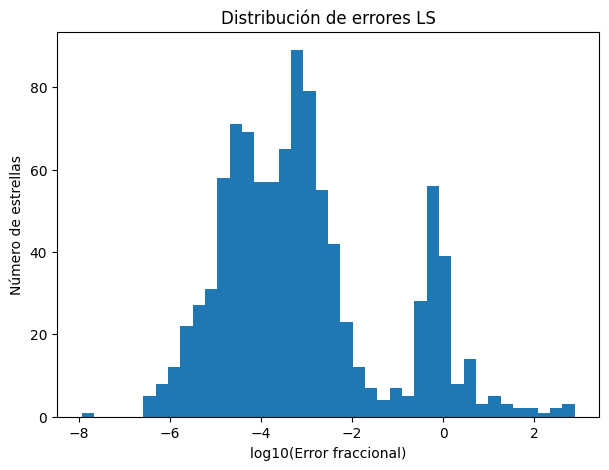

In [64]:
plt.figure(figsize=(7,5))
plt.hist(np.log10(features_df["Frac_Error"].dropna()),bins=40)
plt.xlabel("log10(Error fraccional)")
plt.ylabel("Número de estrellas")
plt.title("Distribución de errores LS")
plt.show()

In [65]:
bad = features_df[features_df["Frac_Error"] > 0.5]
print(len(bad))
print(bad["Tipo"].value_counts())
print(bad[["ID","Tipo","Subtipo","Periodo_OGLE","Periodo_LS","Frac_Error"]])

117
Tipo
LPV      57
ECL      25
OTHER    19
ELL      11
RRLYR     4
DCEP      1
Name: count, dtype: int64
                 ID   Tipo Subtipo  Periodo_OGLE  Periodo_LS  Frac_Error
6      LMC571.20.28    LPV   OSARG     15.493000   34.849895    1.249396
13    LMC562.14.106    ECL    None      2.044910    3.893678    0.904083
17   LMC570.11.5758  RRLYR    RRab      0.482286    0.933901    0.936404
22      LMC563.26.9  OTHER    None      1.360650  823.776950  604.428986
36   LMC570.28.1333    ECL    None      0.910379    1.820818    1.000066
..              ...    ...     ...           ...         ...         ...
969  LMC571.30.1171    ECL    None      2.090075    0.675794    0.676665
974   LMC562.23.165  OTHER    None     19.950000    0.949823    0.952390
979  LMC571.11.4495    LPV   OSARG     14.161000   62.229148    3.394404
981    LMC563.31.55    ELL    None    114.540000   57.206733    0.500552
997  LMC570.30.3312    ECL    None      0.959039    1.846945    0.925829

[117 rows x 6 co

In [66]:
good = features_df[features_df["Frac_Error"] < 0.1]
print(len(good) / len(features_df))

0.799


Estamos teniendo problemas con las eclipsantes(as expected), y con las LPVs, ir a mirar tantos periodos posibles nos está matando un poco...

In [67]:
def folded_lightcurve(t, mag, period):
    phase = phase_fold(t, period)
    idx = np.argsort(phase)
    phase = phase[idx]
    mag = mag[idx]
    phase2 = np.concatenate([phase,phase + 1])
    mag2 = np.concatenate([mag,mag])
    return phase2, mag2

In [68]:
def smooth_folded_curve(phase,mag,nbins=120,smooth_window=11,polyorder=3):
    bins = np.linspace(0, 2, nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    binned_mag = np.full(nbins,np.nan)

    for i in range(nbins):
        mask = ((phase >= bins[i])&(phase < bins[i+1]))
        if np.sum(mask) > 0:
            binned_mag[i] = np.median(mag[mask])
    valid = np.isfinite(binned_mag)
    x = bin_centers[valid]
    y = binned_mag[valid]
    if len(x) < 5:
        return bin_centers, binned_mag

    interp = interp1d(x,y,kind="cubic",fill_value="extrapolate")
    smooth_mag = interp(bin_centers)

    if smooth_window >= len(smooth_mag):
        smooth_window = len(smooth_mag) - 1

    if smooth_window % 2 == 0:
        smooth_window += 1

    smooth_mag = savgol_filter(smooth_mag, window_length=smooth_window,polyorder=polyorder)
    return bin_centers, smooth_mag

Cambiando de tema, lo siguiente trabaja cosas de máximos y mínimos, no parece muy útil excepto para max->min de pulsantes. Consideremos quitar esta parte.

In [69]:
"""def alternating_extrema_clean(
    phase,
    smooth_mag,
    minima_idx,
    maxima_idx
):

    extrema = []

    # ========================================================
    # Mínimos
    # ========================================================

    for idx in minima_idx:

        extrema.append({
            "idx": idx,
            "phase": phase[idx],
            "mag": smooth_mag[idx],
            "type": "min"
        })

    # ========================================================
    # Máximos
    # ========================================================

    for idx in maxima_idx:

        extrema.append({
            "idx": idx,
            "phase": phase[idx],
            "mag": smooth_mag[idx],
            "type": "max"
        })

    # ========================================================
    # Ordenar por fase
    # ========================================================

    extrema = sorted(
        extrema,
        key=lambda x: x["phase"]
    )

    cleaned = []

    # ========================================================
    # Limpiar consecutivos
    # ========================================================

    for ext in extrema:

        if len(cleaned) == 0:

            cleaned.append(ext)

            continue

        last = cleaned[-1]

        # ----------------------------------------------------
        # Alternancia normal
        # ----------------------------------------------------

        if ext["type"] != last["type"]:

            cleaned.append(ext)

            continue

        # ====================================================
        # DOS MÍNIMOS
        # ====================================================
        # conservar el MÁS profundo
        # magnitud MÁS GRANDE
        # ====================================================

        if ext["type"] == "min":

            if ext["mag"] > last["mag"]:

                cleaned[-1] = ext

        # ====================================================
        # DOS MÁXIMOS
        # ====================================================
        # conservar el MÁS brillante
        # magnitud MÁS PEQUEÑA
        # ====================================================

        else:

            if ext["mag"] < last["mag"]:

                cleaned[-1] = ext

    # ========================================================
    # Separar nuevamente
    # ========================================================

    minima_keep = np.array([
        e["idx"]
        for e in cleaned
        if e["type"] == "min"
    ])

    maxima_keep = np.array([
        e["idx"]
        for e in cleaned
        if e["type"] == "max"
    ])

    return minima_keep, maxima_keep"""


'def alternating_extrema_clean(\n    phase,\n    smooth_mag,\n    minima_idx,\n    maxima_idx\n):\n\n    extrema = []\n\n    # ========================================================\n    # Mínimos\n    # ========================================================\n\n    for idx in minima_idx:\n\n        extrema.append({\n            "idx": idx,\n            "phase": phase[idx],\n            "mag": smooth_mag[idx],\n            "type": "min"\n        })\n\n    # ========================================================\n    # Máximos\n    # ========================================================\n\n    for idx in maxima_idx:\n\n        extrema.append({\n            "idx": idx,\n            "phase": phase[idx],\n            "mag": smooth_mag[idx],\n            "type": "max"\n        })\n\n    # ========================================================\n    # Ordenar por fase\n    # ========================================================\n\n    extrema = sorted(\n        extrema,\n        

In [70]:
"""def extract_shape_features(
    phase,
    mag,
    n_extrema=4
):

    # ========================================================
    # Curva suavizada
    # ========================================================

    smooth_phase, smooth_mag = smooth_folded_curve(
        phase,
        mag
    )

    # ========================================================
    # Amplitud robusta
    # ========================================================

    amp = (
        np.percentile(smooth_mag, 95)
        -
        np.percentile(smooth_mag, 5)
    )

    prominence = 0.15 * amp

    # ========================================================
    # Detectar mínimos
    # ========================================================

    minima_idx, _ = find_peaks(
        smooth_mag,
        distance=10,
        prominence=prominence
    )

    # ========================================================
    # Detectar máximos
    # ========================================================

    maxima_idx, _ = find_peaks(
        -smooth_mag,
        distance=10,
        prominence=prominence
    )

    # ========================================================
    # Validación
    # ========================================================

    if (
        len(minima_idx) < 1
        or
        len(maxima_idx) < 1
    ):

        return None

    # ========================================================
    # Limpiar extremos consecutivos
    # ========================================================

    minima_idx, maxima_idx = alternating_extrema_clean(
        smooth_phase,
        smooth_mag,
        minima_idx,
        maxima_idx
    )

    # ========================================================
    # Conservar principales
    # ========================================================

    # mínimos reales:
    # magnitud MÁS GRANDE

    minima_sorted = minima_idx[
        np.argsort(
            smooth_mag[minima_idx]
        )[::-1]
    ]

    minima_keep = minima_sorted[
        :n_extrema
    ]

    # máximos reales:
    # magnitud MÁS PEQUEÑA

    maxima_sorted = maxima_idx[
        np.argsort(
            smooth_mag[maxima_idx]
        )
    ]

    maxima_keep = maxima_sorted[
        :n_extrema
    ]

    # ========================================================
    # Ordenar por fase
    # ========================================================

    minima_keep = minima_keep[
        np.argsort(
            smooth_phase[minima_keep]
        )
    ]

    maxima_keep = maxima_keep[
        np.argsort(
            smooth_phase[maxima_keep]
        )
    ]

    # ========================================================
    # Valores finales
    # ========================================================

    minima_phase = smooth_phase[
        minima_keep
    ]

    maxima_phase = smooth_phase[
        maxima_keep
    ]

    minima_mag = smooth_mag[
        minima_keep
    ]

    maxima_mag = smooth_mag[
        maxima_keep
    ]

    # ========================================================
    # Δ mínimo → máximo
    # ========================================================

    delta_min_to_max = []

    for pmin in minima_phase:

        future_max = maxima_phase[
            maxima_phase > pmin
        ]

        if len(future_max) == 0:

            future_max = maxima_phase + 1

        nearest_max = future_max[0]

        delta = (
            nearest_max - pmin
        ) % 1

        delta_min_to_max.append(delta)

    # ========================================================
    # Δ máximo → mínimo
    # ========================================================

    delta_max_to_min = []

    for pmax in maxima_phase:

        future_min = minima_phase[
            minima_phase > pmax
        ]

        if len(future_min) == 0:

            future_min = minima_phase + 1

        nearest_min = future_min[0]

        delta = (
            nearest_min - pmax
        ) % 1

        delta_max_to_min.append(delta)

    # ========================================================
    # Diferencias entre mínimos
    # ========================================================

    minima_diff = []

    for i in range(
        len(minima_mag) - 1
    ):

        minima_diff.append(
            abs(
                minima_mag[i+1]
                -
                minima_mag[i]
            )
        )

    # ========================================================
    # Diferencias entre máximos
    # ========================================================

    maxima_diff = []

    for i in range(
        len(maxima_mag) - 1
    ):

        maxima_diff.append(
            abs(
                maxima_mag[i+1]
                -
                maxima_mag[i]
            )
        )

    # ========================================================
    # Amplitud total
    # ========================================================

    amplitude = (
        np.max(minima_mag)
        -
        np.min(maxima_mag)
    )

    # ========================================================
    # Output
    # ========================================================

    return {"Amplitude": amplitude,"Mean_MinMax_Delta":
            np.mean(delta_min_to_max),
            "Mean_MaxMin_Delta":
            np.mean(delta_max_to_min),
            "Mean_Minima_Diff":
            np.mean(minima_diff)
            if len(minima_diff) > 0 else np.nan, "Mean_Maxima_Diff":
            np.mean(maxima_diff)
            if len(maxima_diff) > 0 else np.nan, "N_Minima": len(minima_keep),
            "N_Maxima": len(maxima_keep),"smooth_phase": smooth_phase,
            "smooth_mag": smooth_mag,"minima_idx": minima_keep,"maxima_idx": maxima_keep}"""

'def extract_shape_features(\n    phase,\n    mag,\n    n_extrema=4\n):\n\n    # ========================================================\n    # Curva suavizada\n    # ========================================================\n\n    smooth_phase, smooth_mag = smooth_folded_curve(\n        phase,\n        mag\n    )\n\n    # ========================================================\n    # Amplitud robusta\n    # ========================================================\n\n    amp = (\n        np.percentile(smooth_mag, 95)\n        -\n        np.percentile(smooth_mag, 5)\n    )\n\n    prominence = 0.15 * amp\n\n    # ========================================================\n    # Detectar mínimos\n    # ========================================================\n\n    minima_idx, _ = find_peaks(\n        smooth_mag,\n        distance=10,\n        prominence=prominence\n    )\n\n    # ========================================================\n    # Detectar máximos\n    # ======================

Probando sobre 1 star

In [71]:
"""# ============================================================
# Features morfológicas sobre 10 estrellas
# ============================================================

for i, star in sample_stars.iterrows():

    print("="*60)
    print(f"Features estrella {i+1}/10")
    print("ID:", star["ID"])
    print("Tipo:", star["Tipo"])

    # --------------------------------------------------------
    # Cargar datos
    # --------------------------------------------------------

    t, mag, err = load_lightcurve(star["ID"])

    if t is None:
        print("No se pudo cargar.")
        continue

    # --------------------------------------------------------
    # Periodo
    # --------------------------------------------------------

    period_ls, freq, power = lomb_scargle_period(
        t,
        mag,
        star_type=star["Tipo"],
        subtype=star["Subtipo"]
    )

    if np.isnan(period_ls):
        print("Periodo inválido.")
        continue

    # --------------------------------------------------------
    # Fold
    # --------------------------------------------------------

    phase2, mag2 = folded_lightcurve(
        t,
        mag,
        period_ls
    )

    # --------------------------------------------------------
    # Features
    # --------------------------------------------------------

    features = extract_shape_features(
        phase2,
        mag2
    )

    if features is None:
        print("No se pudieron extraer features.")
        continue

    smooth_phase = features["smooth_phase"]
    smooth_mag = features["smooth_mag"]

    minima_idx = features["minima_idx"]
    maxima_idx = features["maxima_idx"]

    # --------------------------------------------------------
    # Mostrar features
    # --------------------------------------------------------

    print("Amplitude:",
          features["Amplitude"])

    print("Mean_MinMax_Delta:",
          features["Mean_MinMax_Delta"])

    print("Mean_MaxMin_Delta:",
          features["Mean_MaxMin_Delta"])

    print("Mean_Minima_Diff:",
          features["Mean_Minima_Diff"])

    print("Mean_Maxima_Diff:",
          features["Mean_Maxima_Diff"])

    # --------------------------------------------------------
    # Gráfica
    # --------------------------------------------------------

    plt.figure(figsize=(8,5))

    # Datos
    plt.scatter(
        phase2,
        mag2,
        s=3,
        alpha=0.4,
        label="Datos"
    )

    # Suavizado
    plt.plot(
        smooth_phase,
        smooth_mag,
        linewidth=2,
        label="Suavizado"
    )

    # Mínimos
    plt.scatter(
        smooth_phase[minima_idx],
        smooth_mag[minima_idx],
        s=60,
        marker="v",
        label="Mínimos"
    )

    # Máximos
    plt.scatter(
        smooth_phase[maxima_idx],
        smooth_mag[maxima_idx],
        s=60,
        marker="^",
        label="Máximos"
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Fase")
    plt.ylabel("Magnitud")

    plt.title(
        f"{star['ID']} | Features morfológicas"
    )

    plt.legend()

    plt.show()"""

'# ============================================================\n# Features morfológicas sobre 10 estrellas\n# ============================================================\n\nfor i, star in sample_stars.iterrows():\n\n    print("="*60)\n    print(f"Features estrella {i+1}/10")\n    print("ID:", star["ID"])\n    print("Tipo:", star["Tipo"])\n\n    # --------------------------------------------------------\n    # Cargar datos\n    # --------------------------------------------------------\n\n    t, mag, err = load_lightcurve(star["ID"])\n\n    if t is None:\n        print("No se pudo cargar.")\n        continue\n\n    # --------------------------------------------------------\n    # Periodo\n    # --------------------------------------------------------\n\n    period_ls, freq, power = lomb_scargle_period(\n        t,\n        mag,\n        star_type=star["Tipo"],\n        subtype=star["Subtipo"]\n    )\n\n    if np.isnan(period_ls):\n        print("Periodo inválido.")\n        continue\n

In [72]:
"""feature_rows = []

for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, freq, power = lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"])
        if np.isnan(period_ls):
            continue
        phase2, mag2 = folded_lightcurve(t,mag,period_ls)
        shape_features = extract_shape_features(phase2,mag2)
        if shape_features is None:
            continue
        row = {"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"],
            "Periodo_LS": period_ls,"Amplitude_OGLE": star["Amplitud"]}
        row.update(shape_features)
        feature_rows.append(row)
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue

features_df = pd.DataFrame(feature_rows)

print(features_df.head())
print(features_df.shape)"""

'feature_rows = []\n\nfor _, star in df_train.iterrows():\n    t, mag, err = load_lightcurve(star["ID"])\n    if t is None:\n        continue\n    try:\n        period_ls, freq, power = lomb_scargle_period(t,mag,star_type=star["Tipo"],subtype=star["Subtipo"])\n        if np.isnan(period_ls):\n            continue\n        phase2, mag2 = folded_lightcurve(t,mag,period_ls)\n        shape_features = extract_shape_features(phase2,mag2)\n        if shape_features is None:\n            continue\n        row = {"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"],\n            "Periodo_LS": period_ls,"Amplitude_OGLE": star["Amplitud"]}\n        row.update(shape_features)\n        feature_rows.append(row)\n    except Exception as e:\n        print(f"Error con {star[\'ID\']}: {e}")\n        continue\n\nfeatures_df = pd.DataFrame(feature_rows)\n\nprint(features_df.head())\nprint(features_df.shape)'

In [73]:
"""pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

# ============================================================
# SUBCONJUNTOS
# ============================================================

feat_puls = features_df[features_df["Tipo"].isin(pulsantes)]
feat_bin = features_df[features_df["Tipo"].isin(binarias)]
feat_lpv = features_df[features_df["Tipo"].isin(lpv)]
feat_other = features_df[features_df["Tipo"].isin(other)]"""

'pulsantes = ["RRLYR","DSCT","DCEP"]\nbinarias = ["ECL","ELL"]\nlpv = ["LPV"]\nother = ["OTHER"]\n\n# ============================================================\n# SUBCONJUNTOS\n# ============================================================\n\nfeat_puls = features_df[features_df["Tipo"].isin(pulsantes)]\nfeat_bin = features_df[features_df["Tipo"].isin(binarias)]\nfeat_lpv = features_df[features_df["Tipo"].isin(lpv)]\nfeat_other = features_df[features_df["Tipo"].isin(other)]'

In [74]:
"""plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes")

plt.hist(
    feat_bin["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias")

plt.hist(
    feat_lpv["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV")

plt.hist(
    feat_other["Mean_MinMax_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER")

plt.xlabel("Δ fase: mínimo → máximo")
plt.ylabel("Número de estrellas")
plt.title("Distribución de Δ(Min→Max)")
plt.legend()
plt.tight_layout()
plt.show()"""

'plt.figure(figsize=(10,6))\n\nplt.hist(\n    feat_puls["Mean_MinMax_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Pulsantes")\n\nplt.hist(\n    feat_bin["Mean_MinMax_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Binarias")\n\nplt.hist(\n    feat_lpv["Mean_MinMax_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="LPV")\n\nplt.hist(\n    feat_other["Mean_MinMax_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="OTHER")\n\nplt.xlabel("Δ fase: mínimo → máximo")\nplt.ylabel("Número de estrellas")\nplt.title("Distribución de Δ(Min→Max)")\nplt.legend()\nplt.tight_layout()\nplt.show()'

In [75]:
"""plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes"
)

plt.hist(
    feat_bin["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias"
)

plt.hist(
    feat_lpv["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV"
)

plt.hist(
    feat_other["Mean_MaxMin_Delta"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER"
)

plt.xlabel("Δ fase: máximo → mínimo")

plt.ylabel("Número de estrellas")

plt.title(
    "Distribución de Δ(Max→Min)"
)

plt.legend()

plt.tight_layout()

plt.show()"""

'plt.figure(figsize=(10,6))\n\nplt.hist(\n    feat_puls["Mean_MaxMin_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Pulsantes"\n)\n\nplt.hist(\n    feat_bin["Mean_MaxMin_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Binarias"\n)\n\nplt.hist(\n    feat_lpv["Mean_MaxMin_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="LPV"\n)\n\nplt.hist(\n    feat_other["Mean_MaxMin_Delta"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="OTHER"\n)\n\nplt.xlabel("Δ fase: máximo → mínimo")\n\nplt.ylabel("Número de estrellas")\n\nplt.title(\n    "Distribución de Δ(Max→Min)"\n)\n\nplt.legend()\n\nplt.tight_layout()\n\nplt.show()'

In [76]:
"""plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes"
)

plt.hist(
    feat_bin["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias"
)

plt.hist(
    feat_lpv["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV"
)

plt.hist(
    feat_other["Mean_Minima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER"
)

plt.xlabel("Diferencia entre mínimos")

plt.ylabel("Número de estrellas")

plt.title(
    "Distribución de diferencias entre mínimos"
)

plt.legend()

plt.tight_layout()
plt.xscale("log")
plt.show()"""

'plt.figure(figsize=(10,6))\n\nplt.hist(\n    feat_puls["Mean_Minima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Pulsantes"\n)\n\nplt.hist(\n    feat_bin["Mean_Minima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Binarias"\n)\n\nplt.hist(\n    feat_lpv["Mean_Minima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="LPV"\n)\n\nplt.hist(\n    feat_other["Mean_Minima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="OTHER"\n)\n\nplt.xlabel("Diferencia entre mínimos")\n\nplt.ylabel("Número de estrellas")\n\nplt.title(\n    "Distribución de diferencias entre mínimos"\n)\n\nplt.legend()\n\nplt.tight_layout()\nplt.xscale("log")\nplt.show()'

In [77]:
"""plt.figure(figsize=(10,6))

plt.hist(
    feat_puls["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Pulsantes"
)

plt.hist(
    feat_bin["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="Binarias"
)

plt.hist(
    feat_lpv["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="LPV"
)

plt.hist(
    feat_other["Mean_Maxima_Diff"].dropna(),
    bins=40,
    alpha=0.5,
    label="OTHER"
)

plt.xlabel("Diferencia entre máximos")

plt.ylabel("Número de estrellas")

plt.title(
    "Distribución de diferencias entre máximos"
)

plt.legend()

plt.tight_layout()
plt.xscale("log")
plt.show()"""

'plt.figure(figsize=(10,6))\n\nplt.hist(\n    feat_puls["Mean_Maxima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Pulsantes"\n)\n\nplt.hist(\n    feat_bin["Mean_Maxima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="Binarias"\n)\n\nplt.hist(\n    feat_lpv["Mean_Maxima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="LPV"\n)\n\nplt.hist(\n    feat_other["Mean_Maxima_Diff"].dropna(),\n    bins=40,\n    alpha=0.5,\n    label="OTHER"\n)\n\nplt.xlabel("Diferencia entre máximos")\n\nplt.ylabel("Número de estrellas")\n\nplt.title(\n    "Distribución de diferencias entre máximos"\n)\n\nplt.legend()\n\nplt.tight_layout()\nplt.xscale("log")\nplt.show()'

VAyamos con skewness

In [78]:
def extract_skewness_feature(phase,mag):
    smooth_phase, smooth_mag = smooth_folded_curve(phase,mag)
    valid = np.isfinite(smooth_mag)
    smooth_mag = smooth_mag[valid]
    if len(smooth_mag) < 10:
        return None
    amplitude = (np.percentile(smooth_mag, 95)-np.percentile(smooth_mag, 5))
    # Magnitudes:
    # menor magnitud = más brillante
    # invertimos signo para interpretación física intuitiva
    smooth_mag = (smooth_mag - np.median(smooth_mag)) / np.std(smooth_mag)
    skewness = -skew(smooth_mag)
    return {"Amplitude": amplitude,"Skewness": skewness,
        "smooth_phase": smooth_phase,"smooth_mag": smooth_mag}

In [79]:
feature_rows = []
for _, star in df_train.iterrows():
    t, mag, err = load_lightcurve(star["ID"])
    if t is None:
        continue
    try:
        period_ls, freq, power = lomb_scargle_period(t,mag,
            star_type=star["Tipo"],subtype=star["Subtipo"])
        if np.isnan(period_ls):
            continue
        phase2, mag2 = folded_lightcurve(t,mag,period_ls)
        shape_features = extract_skewness_feature(phase2,mag2)
        if shape_features is None:
            continue
        row = {
            "ID": star["ID"],
            "Tipo": star["Tipo"],
            "Subtipo": star["Subtipo"],
            "Periodo_LS": period_ls,
            "Amplitude_OGLE": star["Amplitud"]
        }
        row.update(shape_features)
        feature_rows.append(row)
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue

features_df = pd.DataFrame(feature_rows)
print(features_df.head())
print(features_df.shape)

               ID   Tipo Subtipo  Periodo_LS  Amplitude_OGLE  Amplitude  \
0  LMC563.08.8034    ECL    None    0.748773           0.204   0.201247   
1  LMC571.01.4321    LPV   OSARG   21.828878           0.017   0.018896   
2  LMC562.21.9858  OTHER    None    1.644931           0.065   0.069911   
3  LMC563.21.3909    ECL    None    0.596521           0.673   0.634493   
4  LMC562.19.8132    ECL    None    0.580774           0.032   0.028485   

   Skewness                                       smooth_phase  \
0 -1.059068  [0.008333333333333333, 0.025, 0.04166666666666...   
1  0.048718  [0.008333333333333333, 0.025, 0.04166666666666...   
2 -0.411580  [0.008333333333333333, 0.025, 0.04166666666666...   
3 -1.691724  [0.008333333333333333, 0.025, 0.04166666666666...   
4 -0.120917  [0.008333333333333333, 0.025, 0.04166666666666...   

                                          smooth_mag  
0  [-0.027251273610926413, 0.12448104609696797, 0...  
1  [-0.12372764326284551, -0.5804801150646

In [80]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

feat_puls = features_df[features_df["Tipo"].isin(pulsantes)]
feat_bin = features_df[features_df["Tipo"].isin(binarias)]
feat_lpv = features_df[features_df["Tipo"].isin(lpv)]
feat_other = features_df[features_df["Tipo"].isin(other)]   

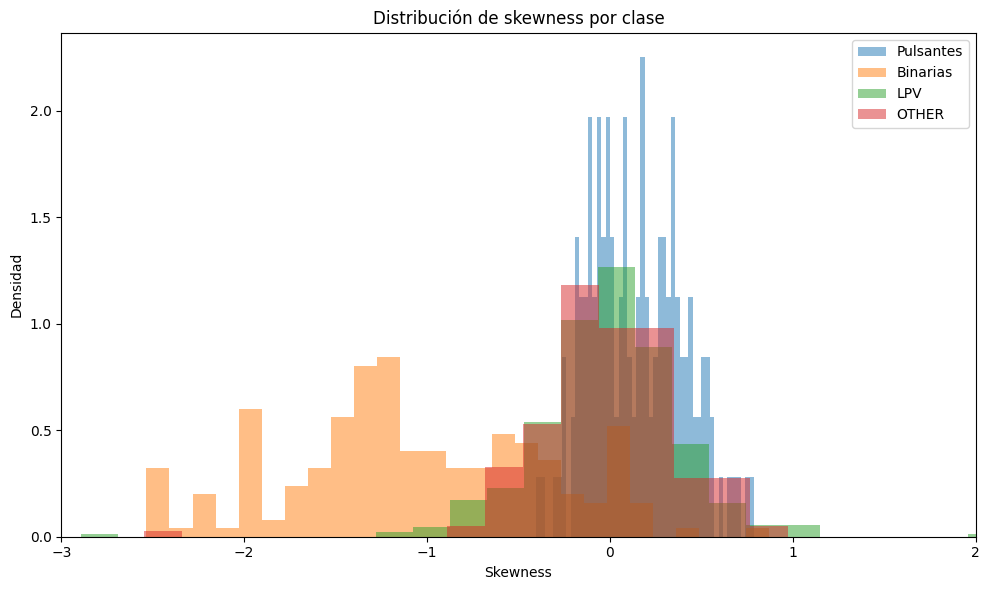

In [81]:
plt.figure(figsize=(10,6))
bins = 50
plt.hist(feat_puls["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="Pulsantes")
plt.hist(feat_bin["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="Binarias")
plt.hist(feat_lpv["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="LPV")
plt.hist(feat_other["Skewness"].dropna(),bins=bins,alpha=0.5,density=True,label="OTHER")
plt.xlabel("Skewness")
plt.ylabel("Densidad")
plt.title("Distribución de skewness por clase")
plt.legend()
plt.xlim(-3, 2)
plt.tight_layout()
plt.show()

Ahora vamos con color

In [82]:
PHOT_I_PATH = "phot/I"
PHOT_V_PATH = "phot/V"

In [83]:
def load_lightcurve(star_id, band="I"):
    if band == "I":
        base_path = PHOT_I_PATH
    elif band == "V":
        base_path = PHOT_V_PATH
    else:
        return None, None, None
    filepath = os.path.join(base_path,f"{star_id}.dat")
    if not os.path.exists(filepath):
        return None, None, None
    try:
        data = np.loadtxt(filepath)
        t = data[:,0]
        mag = data[:,1]
        err = data[:,2]
        return t, mag, err
    except:
        return None, None, None

In [84]:
def extract_color_feature(star_id):
    tI, magI, errI = load_lightcurve(star_id,band="I")

    tV, magV, errV = load_lightcurve(star_id,band="V")

    if magI is None or magV is None:
        return None

    magI = magI[np.isfinite(magI)]
    magV = magV[np.isfinite(magV)]

    if len(magI) < 5 or len(magV) < 5:
        return None

    median_I = np.median(magI)
    median_V = np.median(magV)
    color_VI = median_V - median_I
    return {"Median_I": median_I,"Median_V": median_V,"Color_VI": color_VI}

In [85]:
color_rows = []
for _, star in df_train.iterrows():
    try:
        color_features = extract_color_feature(star["ID"])
        if color_features is None:
            continue
        row = {"ID": star["ID"],"Tipo": star["Tipo"],"Subtipo": star["Subtipo"]}
        row.update(color_features)
        color_rows.append(row)
    except Exception as e:
        print(f"Error con {star['ID']}: {e}")
        continue
color_df = pd.DataFrame(color_rows)
print(color_df.head())
print(color_df.shape)

               ID   Tipo Subtipo  Median_I  Median_V  Color_VI
0  LMC563.08.8034    ECL    None   19.5995    19.623    0.0235
1  LMC571.01.4321    LPV   OSARG   14.9410    16.714    1.7730
2  LMC562.21.9858  OTHER    None   18.2840    18.227   -0.0570
3  LMC563.21.3909    ECL    None   20.3520    20.522    0.1700
4  LMC562.19.8132    ECL    None   15.4070    15.655    0.2480
(952, 6)


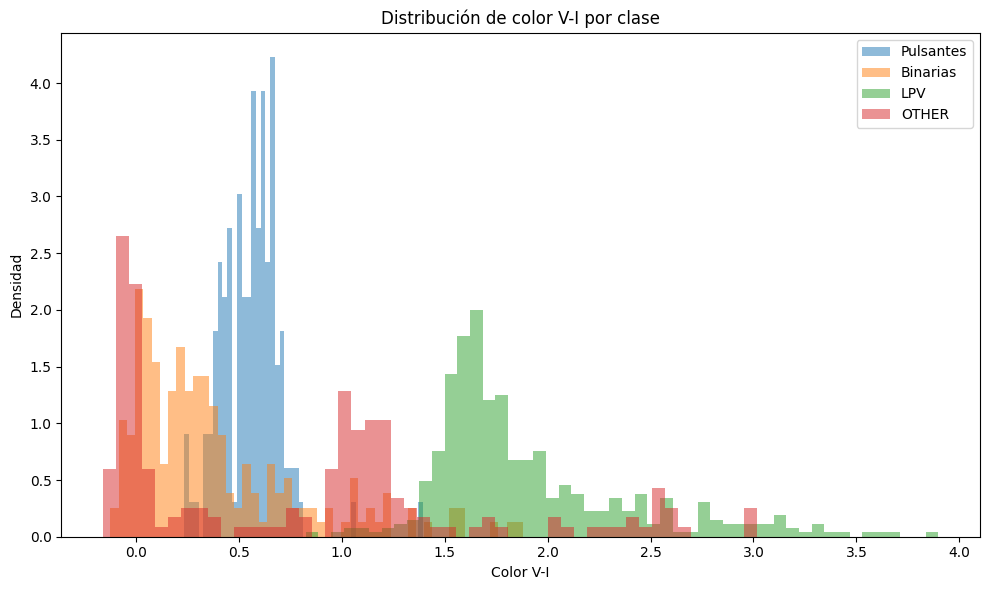

In [86]:
pulsantes = ["RRLYR","DSCT","DCEP"]
binarias = ["ECL","ELL"]
lpv = ["LPV"]
other = ["OTHER"]

color_puls = color_df[color_df["Tipo"].isin(pulsantes)]
color_bin = color_df[color_df["Tipo"].isin(binarias)]
color_lpv = color_df[color_df["Tipo"].isin(lpv)]
color_other = color_df[color_df["Tipo"].isin(other)]

plt.figure(figsize=(10,6))
bins = 50
plt.hist(color_puls["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="Pulsantes")
plt.hist(color_bin["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="Binarias")
plt.hist(color_lpv["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="LPV")
plt.hist(color_other["Color_VI"].dropna(),bins=bins,alpha=0.5,density=True,label="OTHER")
plt.xlabel("Color V-I")
plt.ylabel("Densidad")
plt.title("Distribución de color V-I por clase")
plt.legend()
plt.tight_layout()
plt.show()

Diagrama 3D

In [87]:
merged_df = pd.merge(features_df[["ID","Tipo","Periodo_LS","Skewness"]],
    color_df[["ID","Color_VI"]],on="ID",how="inner")
print(merged_df.head())
print(merged_df.shape)
merged_df = merged_df.replace([np.inf, -np.inf],np.nan)
merged_df = merged_df.dropna()
print(merged_df.shape)
merged_df["LogPeriod"] = np.log10(merged_df["Periodo_LS"])

               ID   Tipo  Periodo_LS  Skewness  Color_VI
0  LMC563.08.8034    ECL    0.748773 -1.059068    0.0235
1  LMC571.01.4321    LPV   21.828878  0.048718    1.7730
2  LMC562.21.9858  OTHER    1.644931 -0.411580   -0.0570
3  LMC563.21.3909    ECL    0.596521 -1.691724    0.1700
4  LMC562.19.8132    ECL    0.580774 -0.120917    0.2480
(924, 5)
(924, 5)


In [88]:
# ============================================================
# REAGRUPAR A SOLO 4 CLASES GRANDES
# ============================================================

def simplify_class(tipo):

    if tipo in ["RRLYR", "DSCT", "DCEP"]:
        return "Pulsantes"

    elif tipo in ["ECL", "ELL"]:
        return "Binarias"

    elif tipo == "LPV":
        return "LPV"

    else:
        return "OTHER"

# Nueva columna
merged_df["Grupo"] = merged_df["Tipo"].apply(simplify_class)

In [89]:
merged_df_plot = merged_df[merged_df["Grupo"] != "OTHER"].copy()
print(merged_df_plot["Grupo"].value_counts())

Grupo
LPV          411
Binarias     189
Pulsantes    140
Name: count, dtype: int64


In [90]:
fig = px.scatter_3d(merged_df,x="LogPeriod",y="Skewness",z="Color_VI",color="Grupo",opacity=0.7,
    title=("Espacio de features:\n""Periodo + Skewness + Color"),
    labels={"LogPeriod": "log10(Periodo)","Skewness": "Skewness","Color_VI": "Color V-I", "Grupo": "Clase"},
    hover_data=["ID", "Tipo"])

fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(xaxis_title="log10(Periodo)",yaxis_title="Skewness",zaxis_title="Color V-I"))
fig.show()